# Templates

Author(s): Raghav Kansal

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib import colors

from boostedhh import utils, hh_vars, plotting
from boostedhh.utils import PAD_VAL, Cutflow
from bbtautau.postprocessing import Samples, Regions, postprocessing
from bbtautau.postprocessing.Samples import CHANNELS, SAMPLES, SIGNALS
import bbtautau.postprocessing.utils as putils
from bbtautau.postprocessing.utils import LoadedSample

import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger("boostedhh.utils")
logger.setLevel(logging.DEBUG)

In [2]:
# automatically reloads imported files on edits
%load_ext autoreload
%autoreload 2

In [3]:
MAIN_DIR = Path("../../../")
CHANNEL = CHANNELS["hh"]  # options: "hh", "he", "hm"

tag = "25Apr23"
year = "2022"

plot_dir = MAIN_DIR / f"plots/Templates/{tag}/{CHANNEL.key}"
plot_dir.mkdir(parents=True, exist_ok=True)

templates_dir = Path(f"./templates/{tag}/{CHANNEL.key}")
(templates_dir / "cutflows" / year).mkdir(parents=True, exist_ok=True)

base_dir = Path("/ceph/users/cramonal/bbtautau/skimmer/")
data_paths = {
    "signal": base_dir,
    "data": base_dir,
    "bg": base_dir,
}

# sigs = {s + CHANNEL.key: SAMPLES[s + CHANNEL.key] for s in SIGNALS}
bgs = {bkey: b for bkey, b in SAMPLES.items() if b.get_type() == "bg"}

In [4]:
from bbtautau.HLTs import HLTs

trigdict = postprocessing.trigger_filter(HLTs.hlts_list_by_dtype(year), year)
# trigdict["signal"]

## Load samples

In [5]:
# dictionary that will contain all information (from all samples)
events_dict = postprocessing.load_samples(
    year,
    CHANNEL,
    data_paths,
    load_data=True,
    load_bgs=True,
    filters_dict=postprocessing.bb_filters(num_fatjets=3, bb_cut=0.8),
    loaded_samples=True,
)
cutflow = utils.Cutflow(samples=events_dict)
# cutflow.add_cut(events_dict, "Preselection", "finalWeight")
# cutflow.cutflow

2025-06-13 02:12:13,370 - INFO - Loading ['Tau_Run2022C', 'Tau_Run2022D']
2025-06-13 02:12:13,371 - DEBUG - Loading Tau_Run2022C
2025-06-13 02:12:37,070 - INFO - Loaded Tau_Run2022C                                      : 28707 entries
2025-06-13 02:12:37,071 - DEBUG - Loading Tau_Run2022D
2025-06-13 02:12:43,022 - INFO - Loaded Tau_Run2022D                                      : 19403 entries
2025-06-13 02:12:43,060 - INFO - Loading ['QCD-4Jets_HT-2000', 'QCD-4Jets_HT-600to800', 'QCD-4Jets_HT-1000to1200', 'QCD-4Jets_HT-1200to1500', 'QCD-4Jets_HT-200to400', 'QCD-4Jets_HT-100to200', 'QCD-4Jets_HT-1500to2000', 'QCD-4Jets_HT-400to600', 'QCD-4Jets_HT-800to1000']
2025-06-13 02:12:43,061 - DEBUG - Loading QCD-4Jets_HT-2000
2025-06-13 02:12:58,598 - INFO - Loaded QCD-4Jets_HT-2000                                 : 135691 entries
2025-06-13 02:12:58,599 - DEBUG - Loading QCD-4Jets_HT-600to800
2025-06-13 02:13:12,889 - INFO - Loaded QCD-4Jets_HT-600to800                             : 107901 entr

Triggers

In [6]:
postprocessing.apply_triggers(events_dict, year, CHANNEL)
cutflow.add_cut(events_dict, "Triggers", "finalWeight")
cutflow.cutflow

['HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet60', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet75', 'HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1']
['HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet60', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet75', 'HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1']
['HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet60', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet75', 'HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1']
['HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet60', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet75', 'HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1']
['HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet60', 'HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet75', 'HLT_Loo

,Triggers
Tau,40633.000000
QCD Multijet,34534.536213
TT Had,512.301803
TT SL,1355.249977
TT LL,700.468335
DY+Jets,105.656306
W+Jets,394.800083
Z+Jets,1191.907711


bbtautau assignment

In [7]:
postprocessing.bbtautau_assignment(events_dict, CHANNEL)

Templates

pass Region: 0.00
pass
{'ak8FatJetPt0': [200, 9999.0]}
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
sel
{'tau': array([ True,  True,  True, ...,  True,  True,  True]), 'qcd': array([ True,  True,  True, ...,  True,  True,  True]), 'ttbarhad': array([ True,  True,  True, ...,  True,  True,  True]), 'ttbarsl': array([ True,  True,  True, ...,  True,  True,  True]), 'ttbarll': array([ True,  True,  True, ...,  True,  True,  True

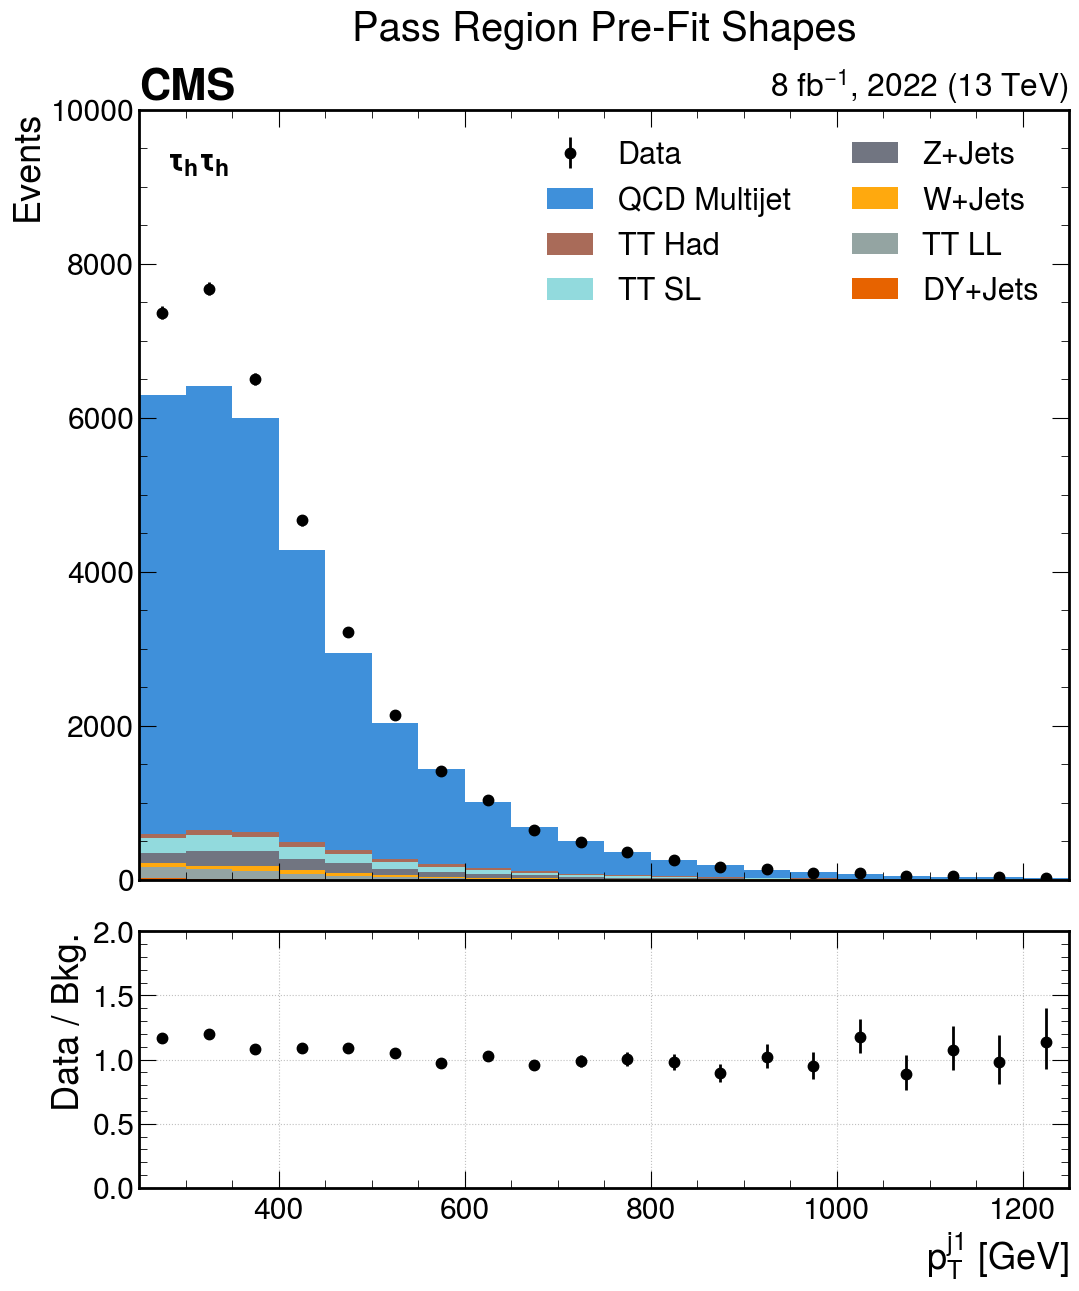

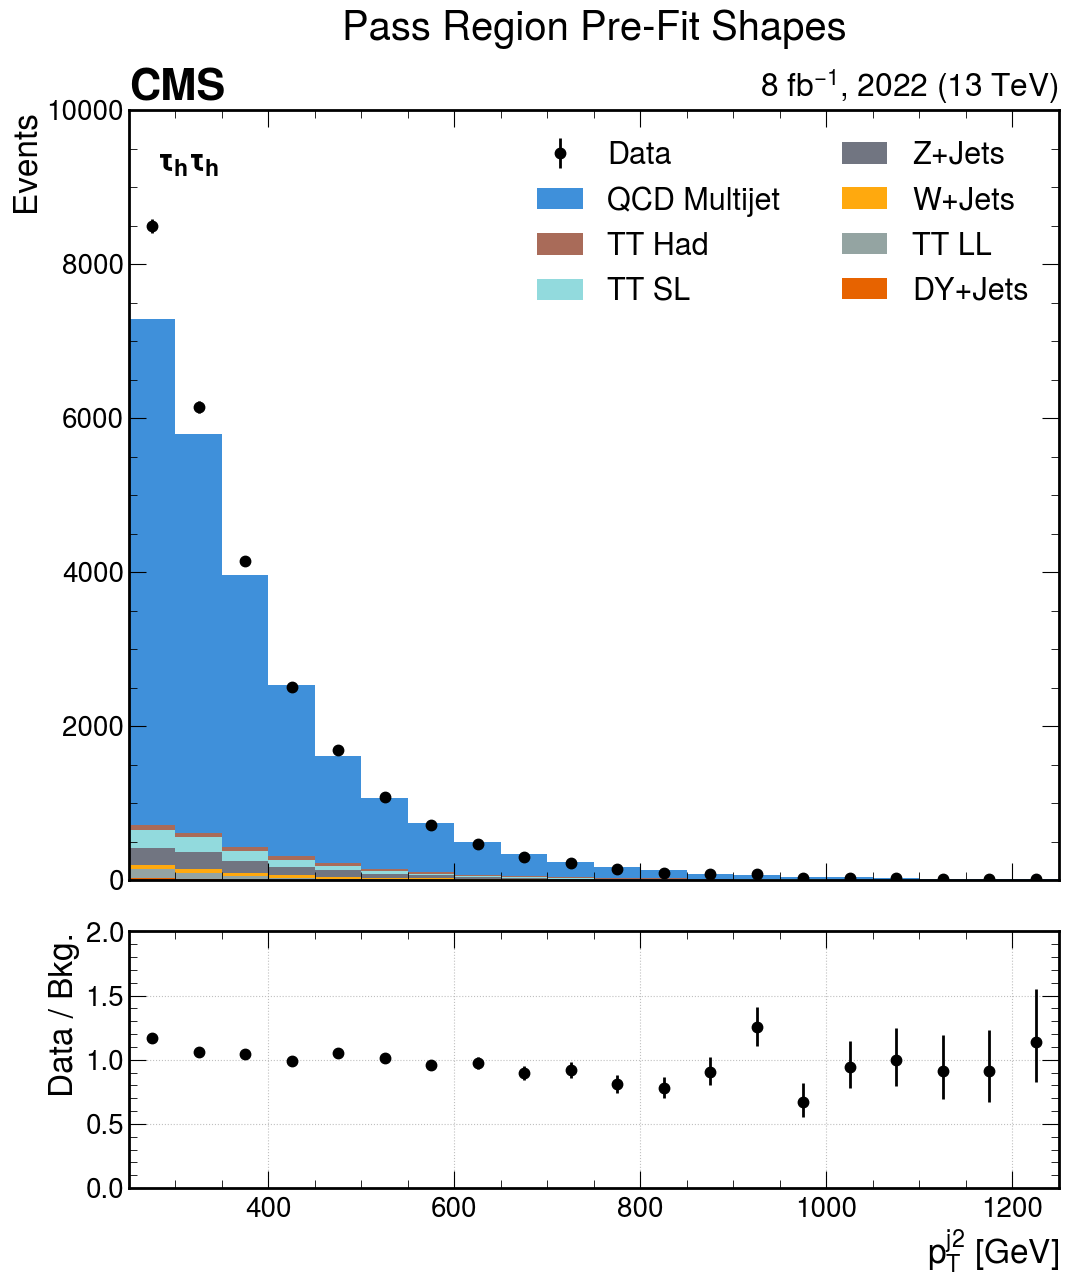

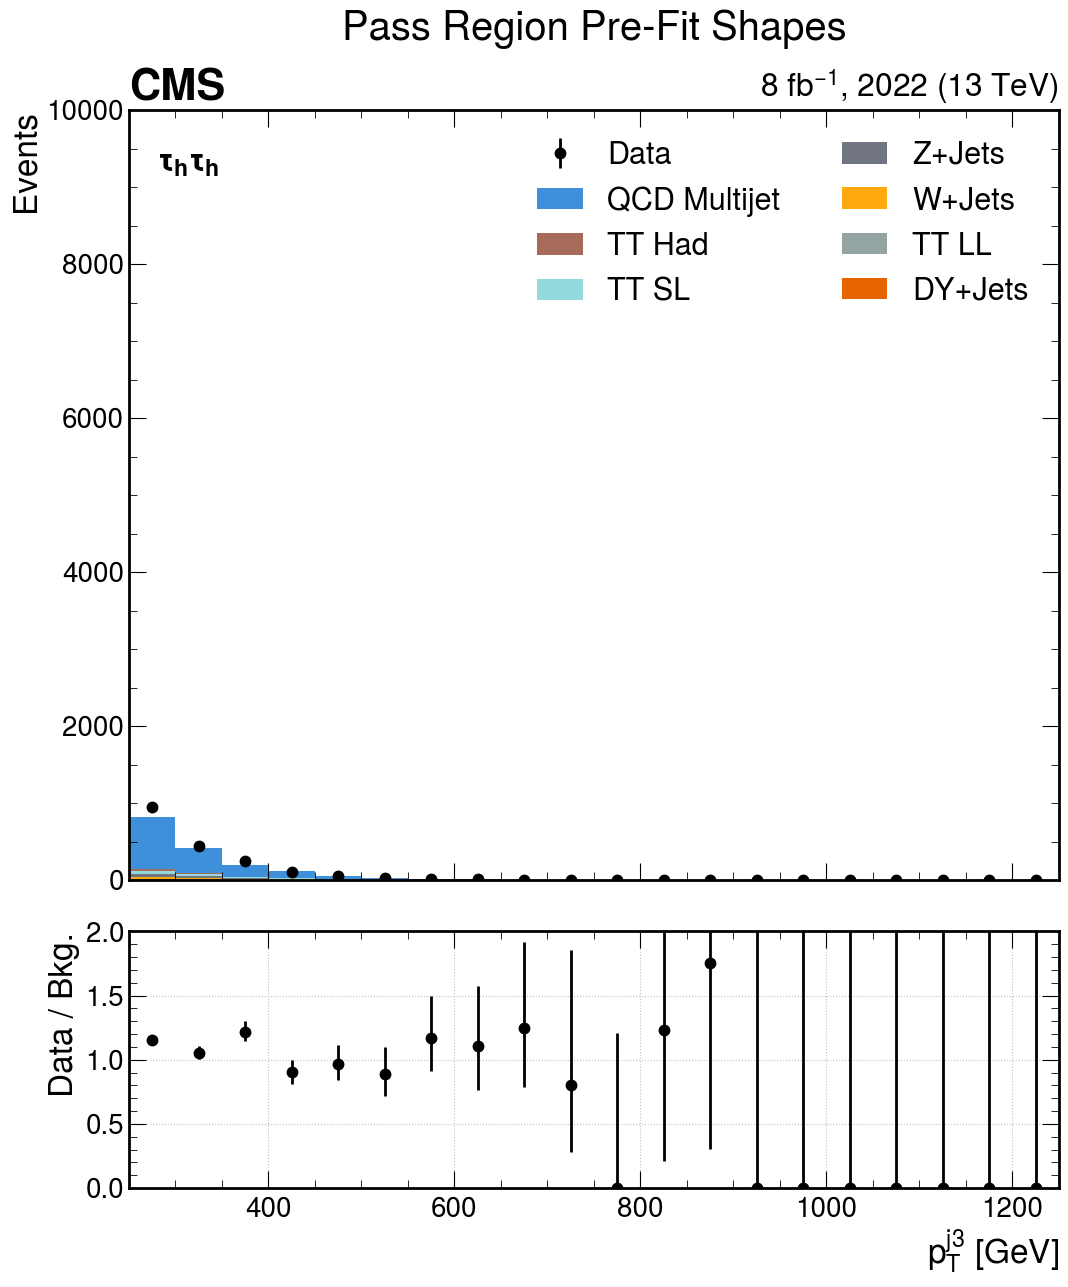

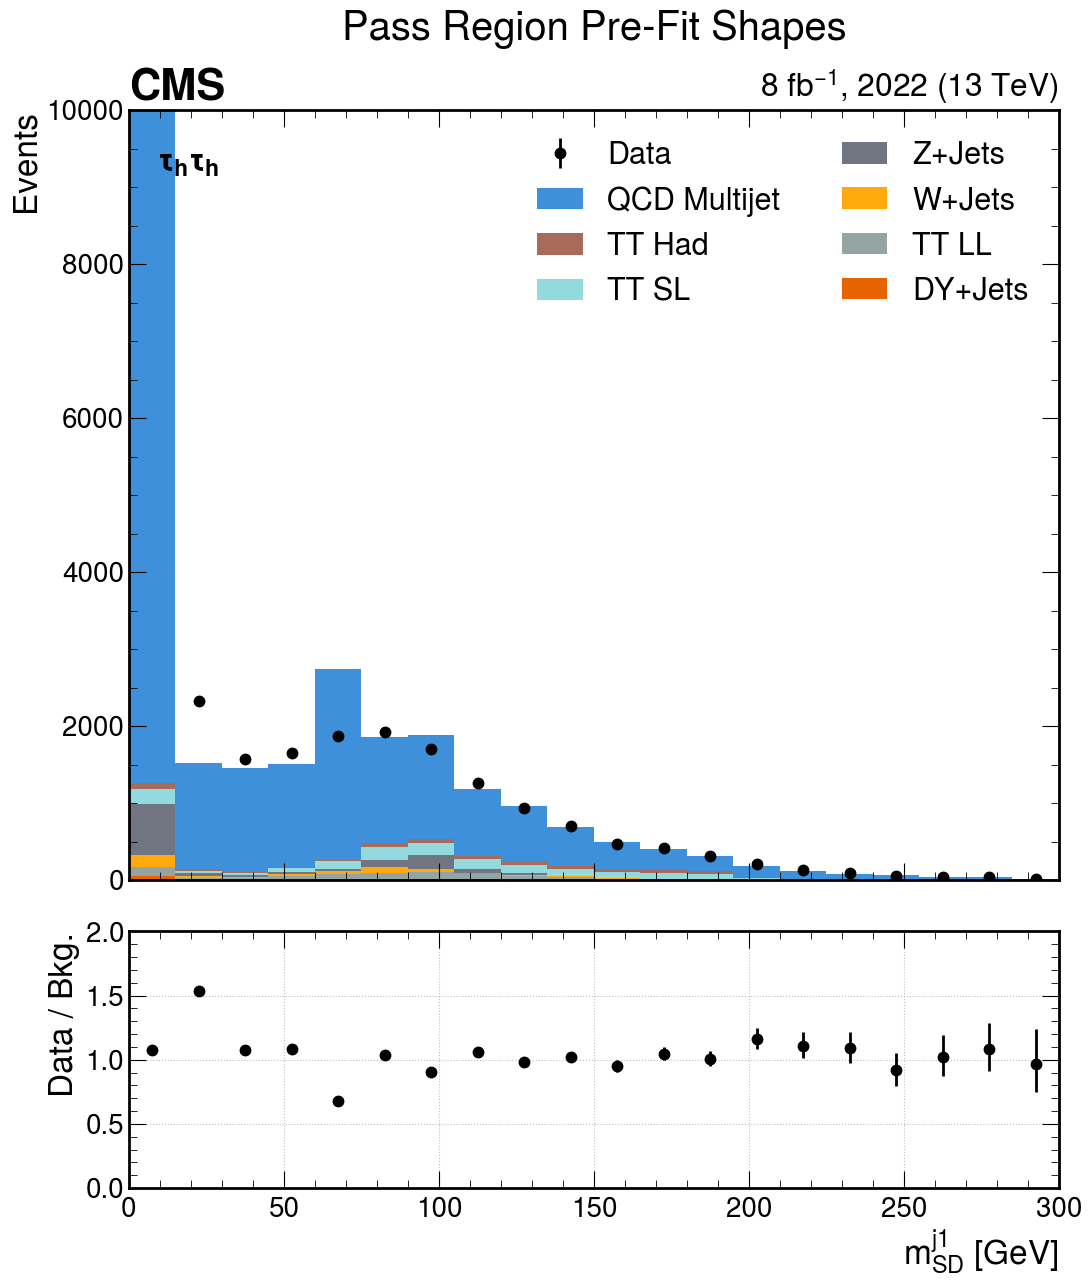

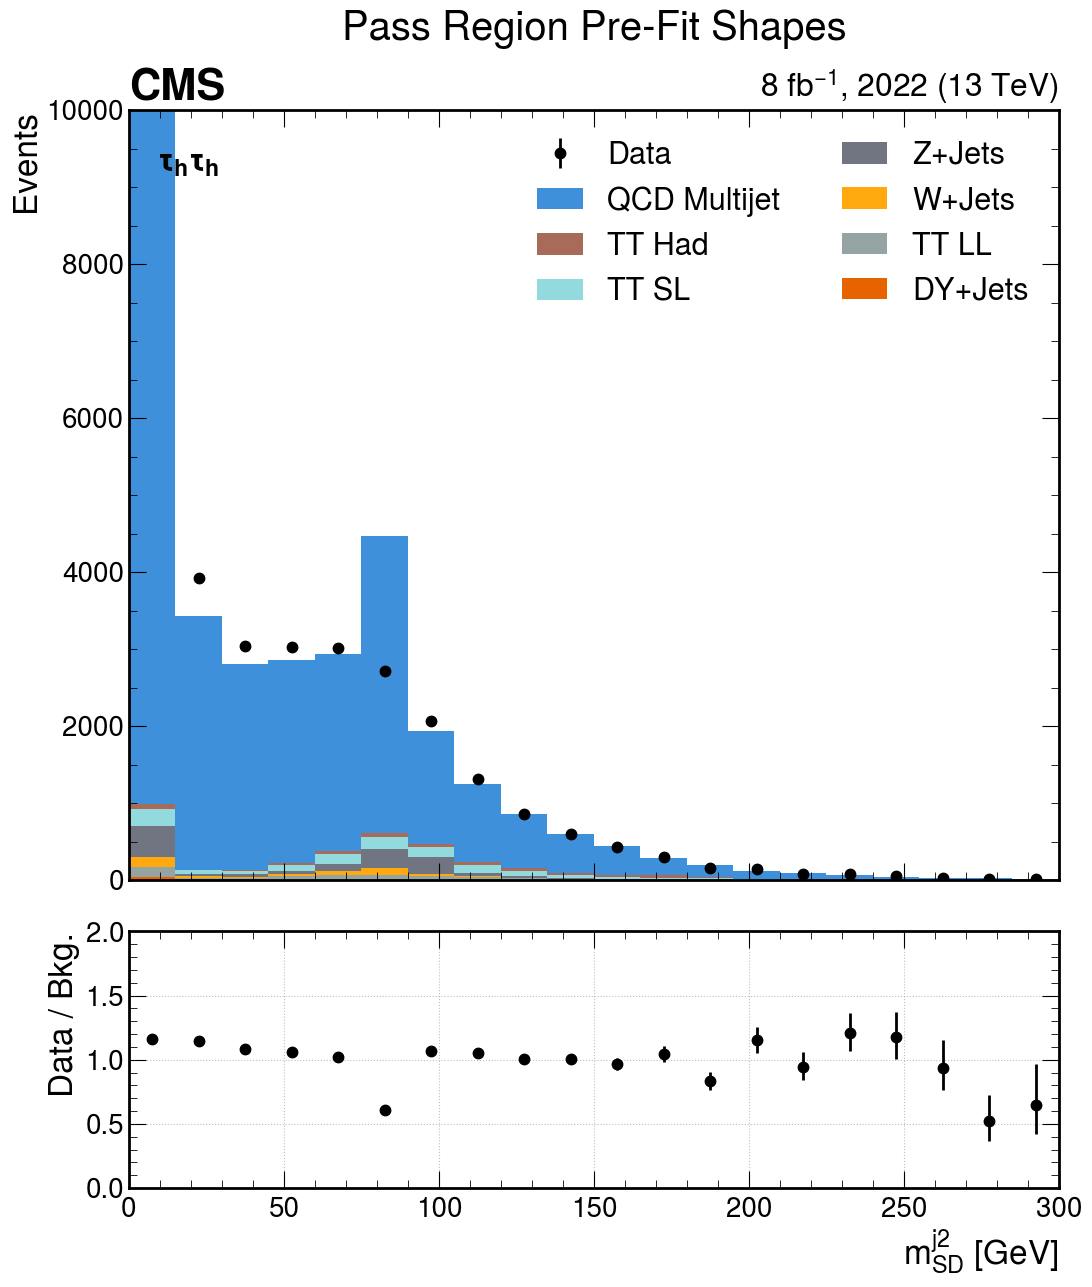

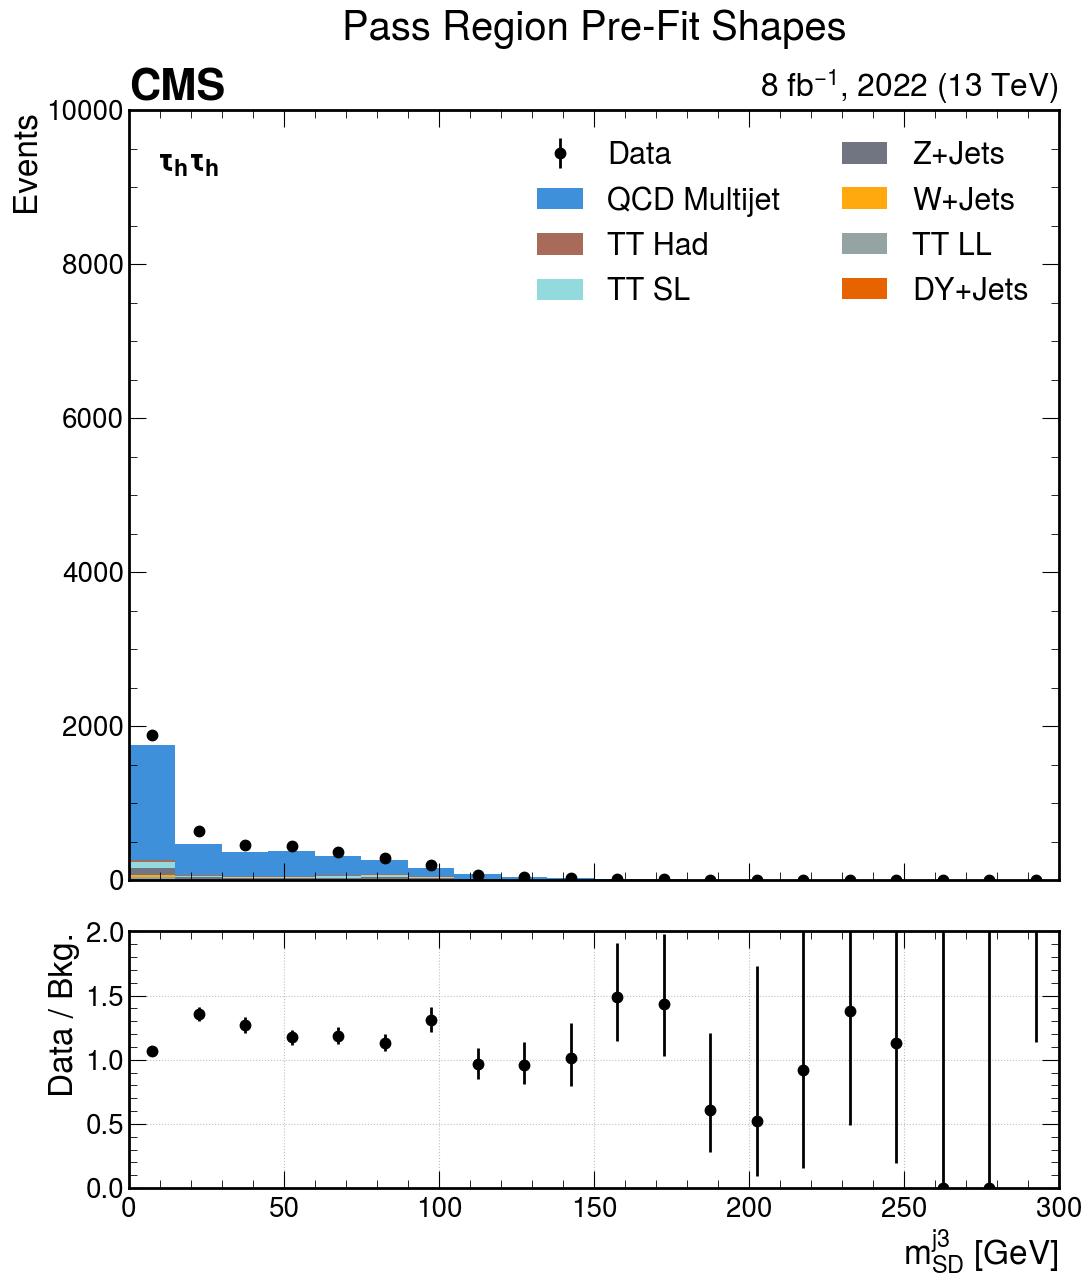

fail Region: 145.84
fail
{'ak8FatJetPt0': [200, 9999.0]}
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
v ak8FatJetPt0
[ True  True  True ...  True  True  True]
ak8FatJetPt0 >= 200
sel
{'tau': array([ True,  True,  True, ...,  True,  True,  True]), 'qcd': array([ True,  True,  True, ...,  True,  True,  True]), 'ttbarhad': array([ True,  True,  True, ...,  True,  True,  True]), 'ttbarsl': array([ True,  True,  True, ...,  True,  True,  True]), 'ttbarll': array([ True,  True,  True, ...,  True,  True,  Tr

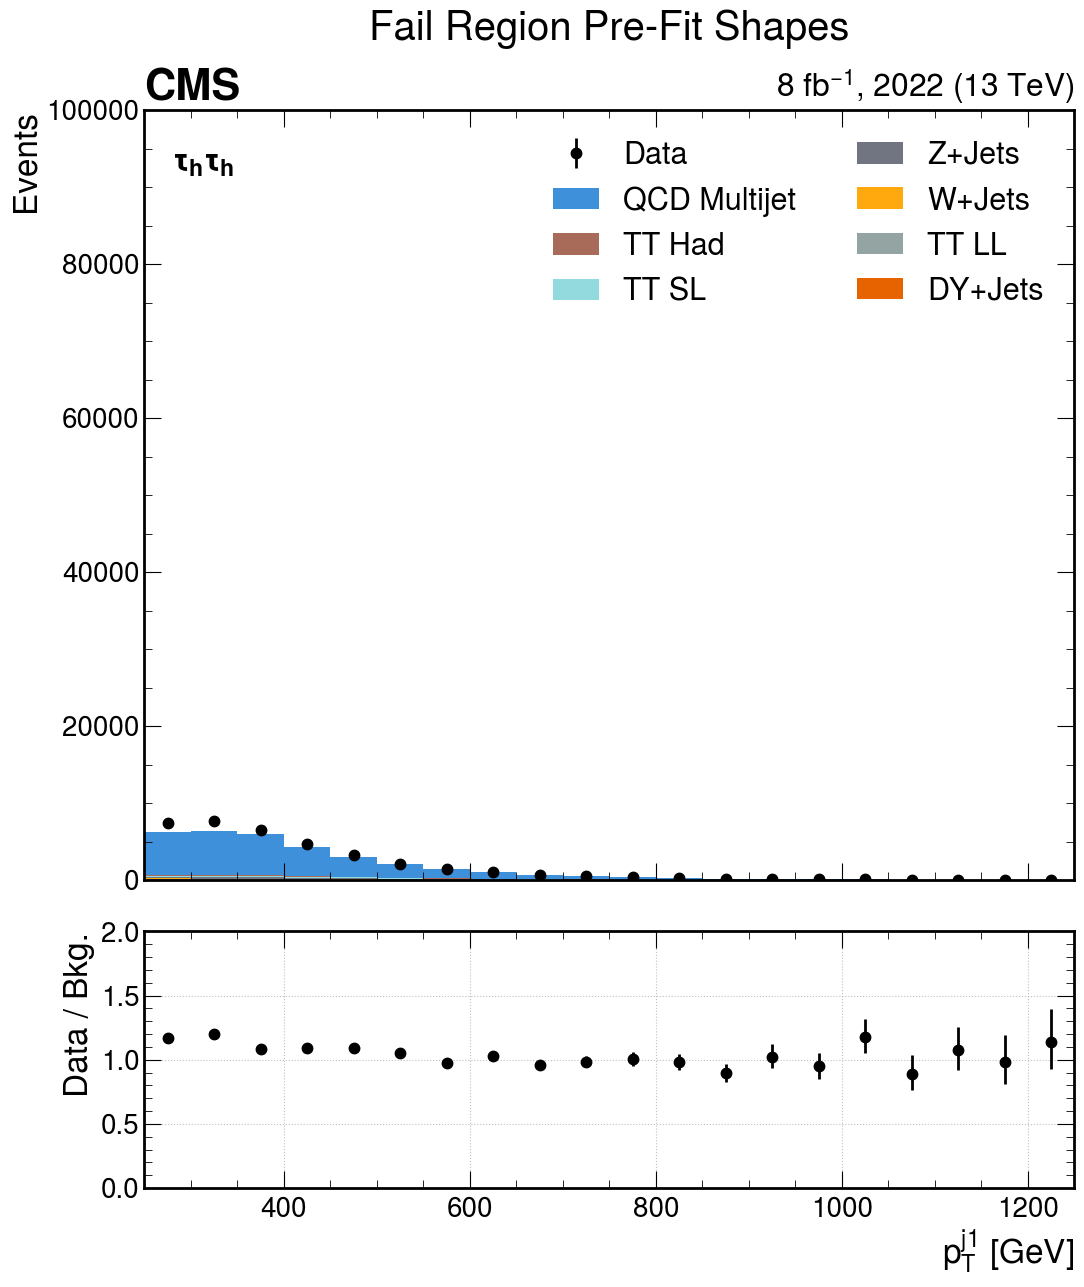

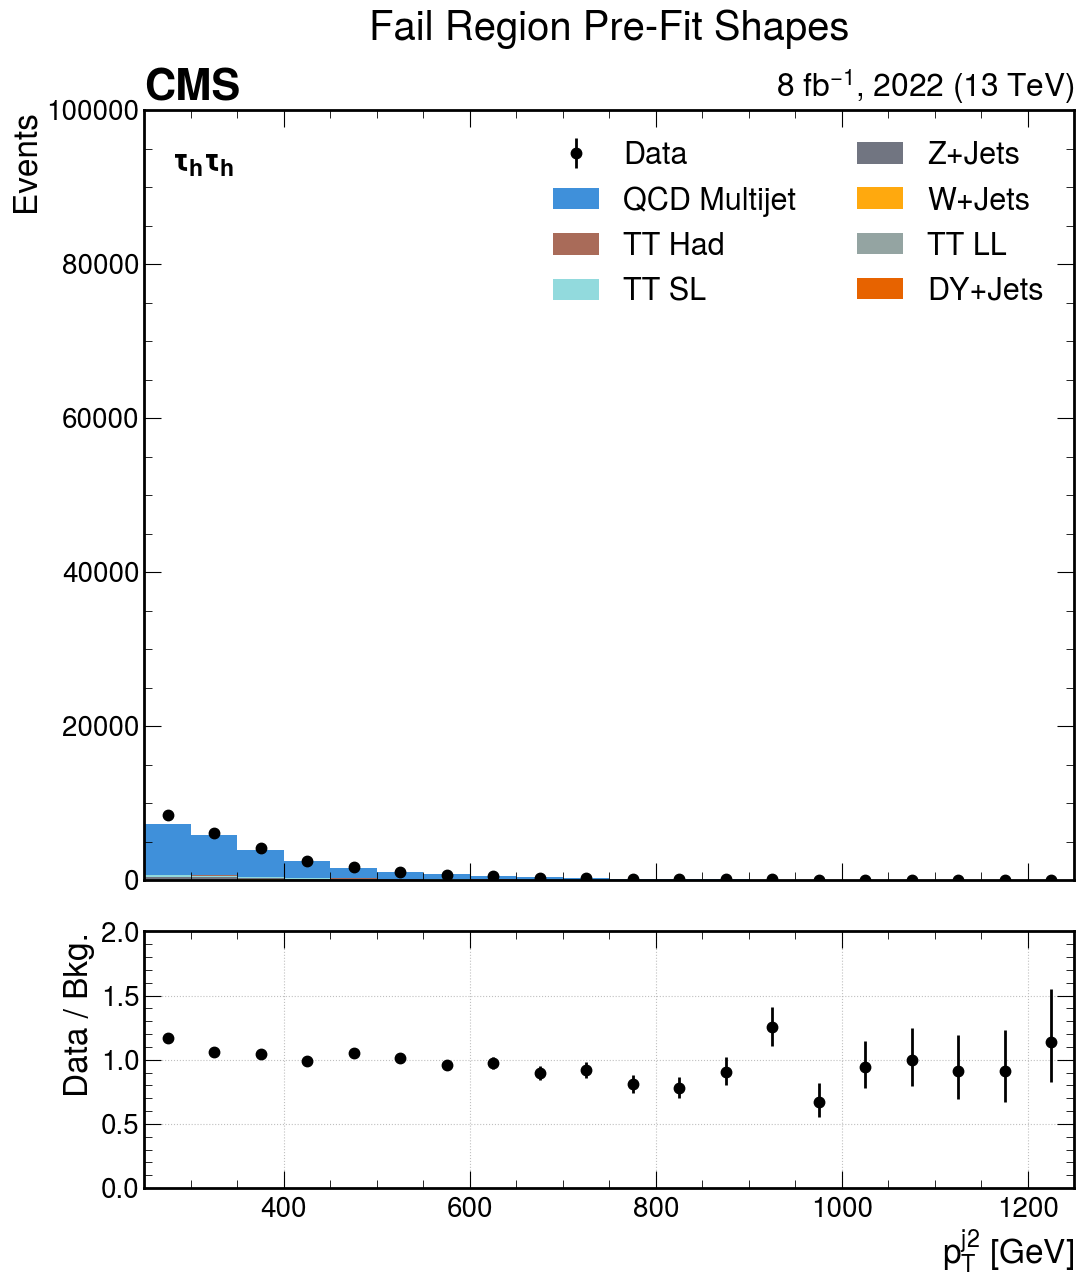

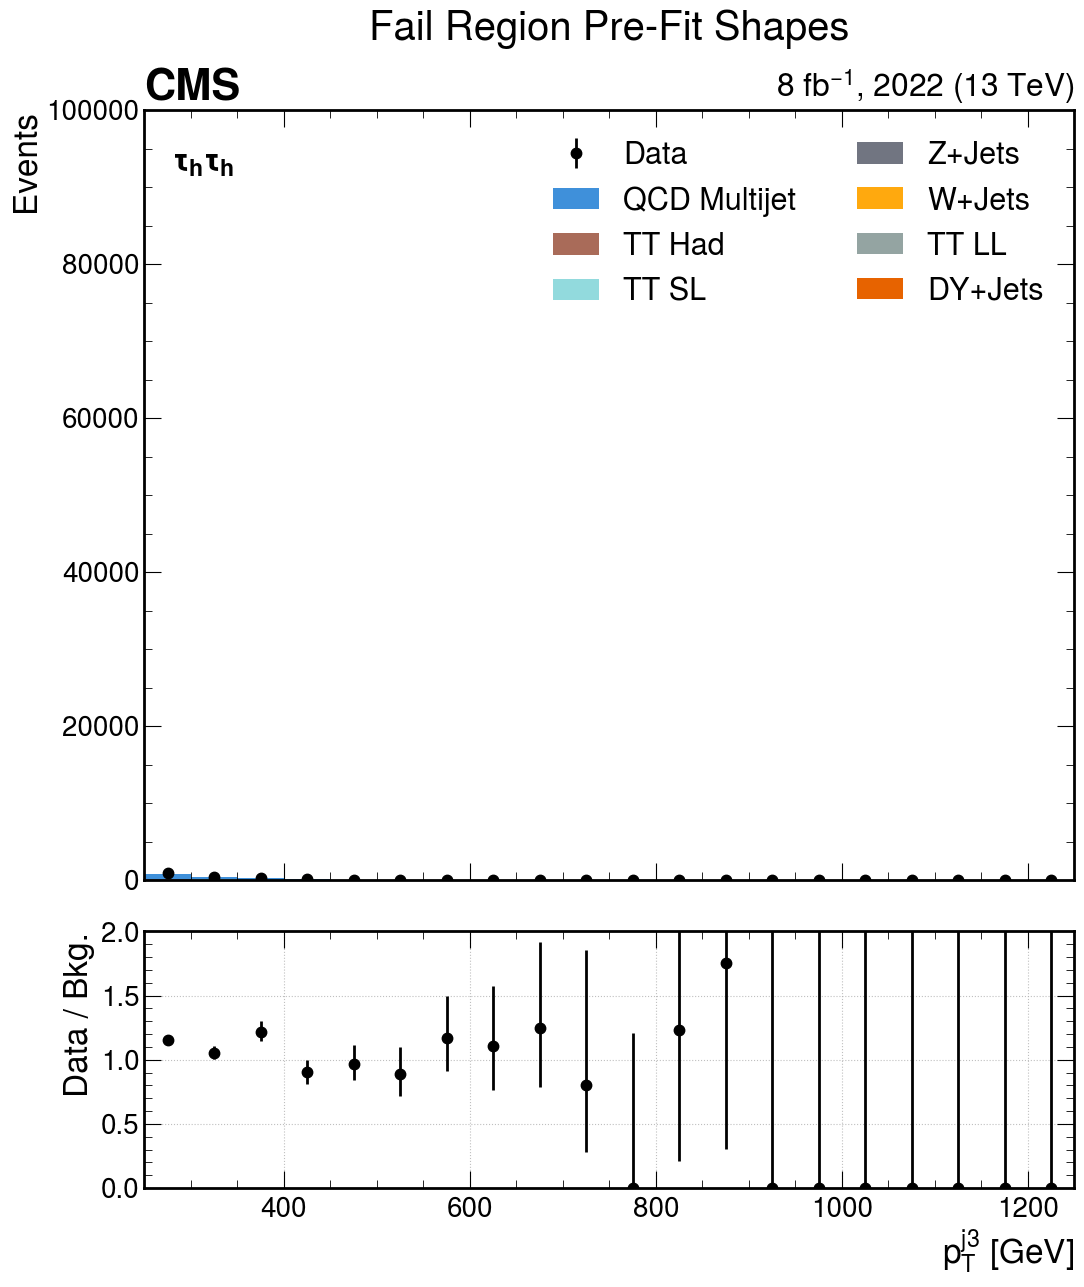

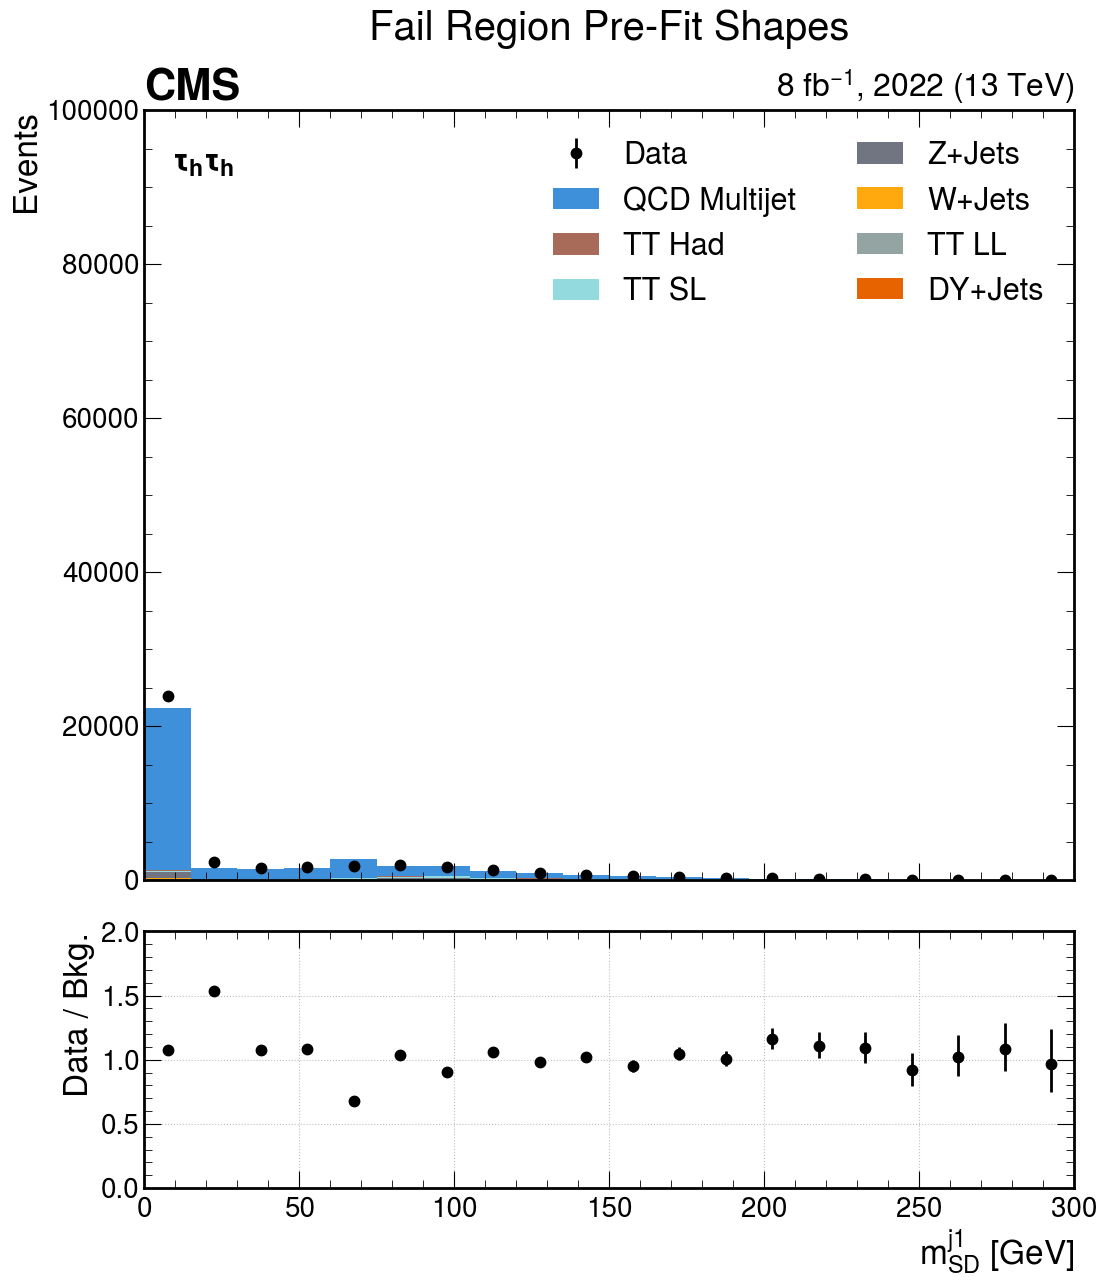

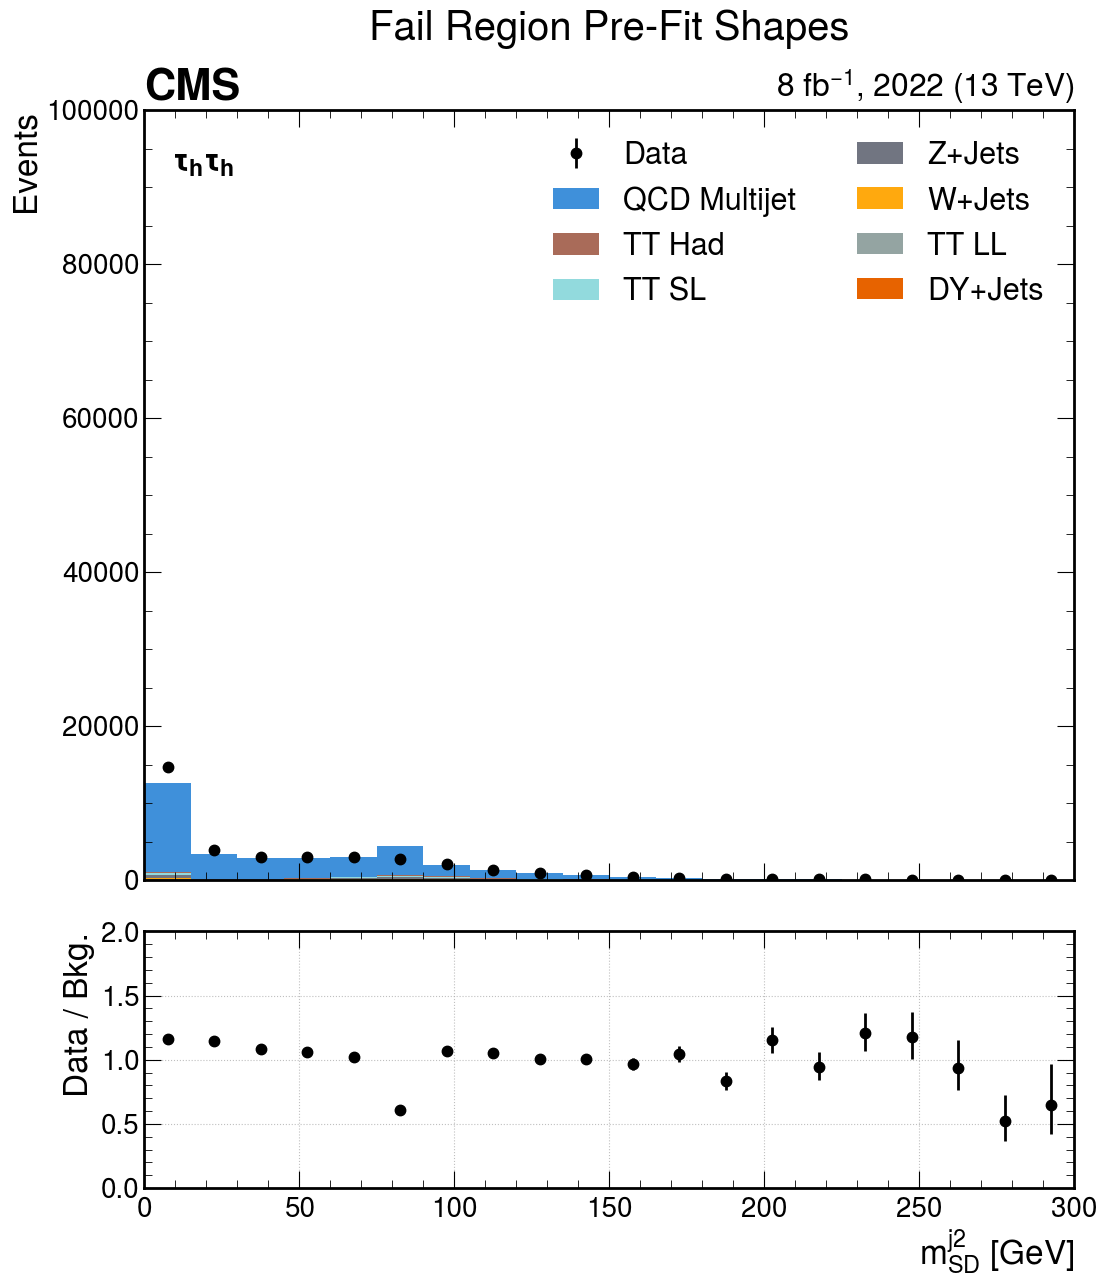

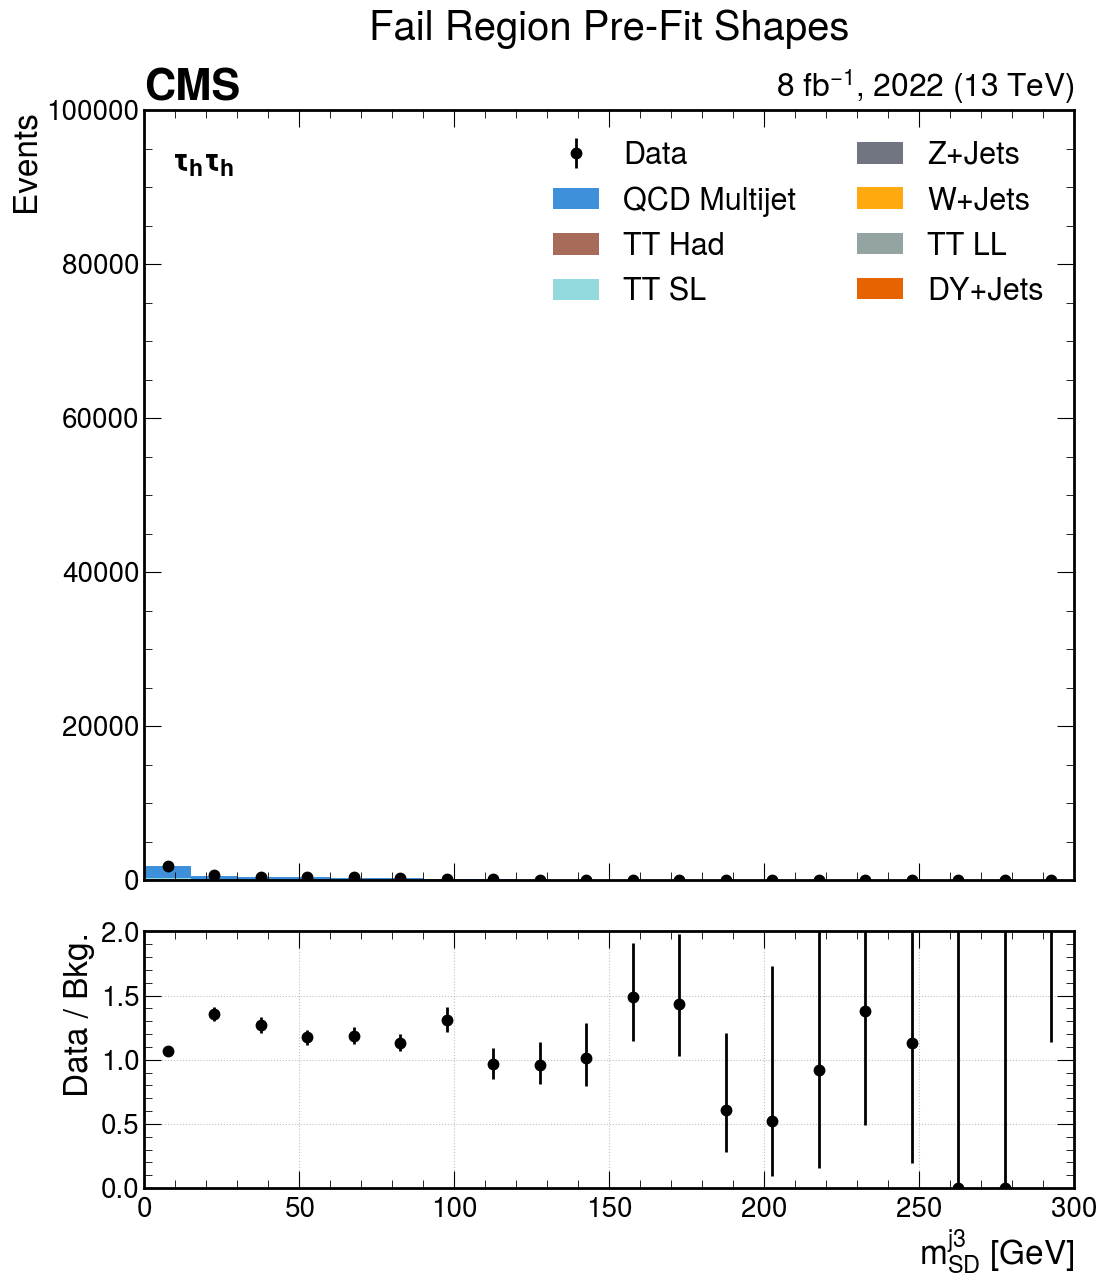

In [9]:
# CHANNEL = Samples.CHANNELS["hh"]  # reload for new cuts
templates = postprocessing.get_templates(
    events_dict,
    year,
    [],
    bgs,
    CHANNEL,
    postprocessing.control_plot_vars,
    {},
    pass_ylim=10e3,
    fail_ylim=1e5,
    sig_scale_dict={},
    plot_dir=plot_dir,
    template_dir=templates_dir,
    show=True,
)

In [9]:
postprocessing.save_templates(
    templates, templates_dir / f"{year}_templates.pkl", True, postprocessing.shape_vars
)

AttributeError: module 'bbtautau.postprocessing.postprocessing' has no attribute 'shape_vars'